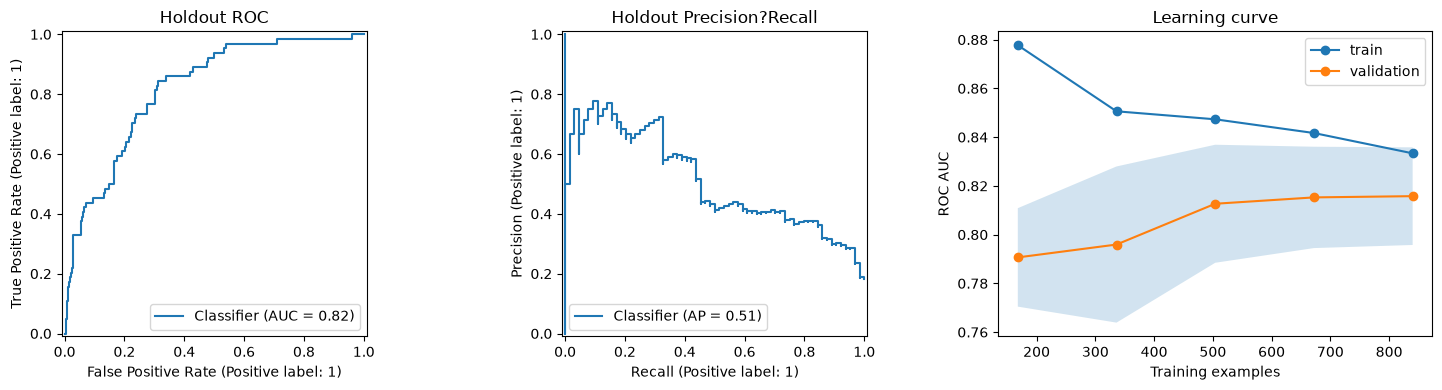

Holdout metrics: {
  "accuracy": 0.7314285714285714,
  "precision": 0.3790322580645161,
  "recall": 0.734375,
  "f1": 0.5,
  "roc_auc": 0.8173076923076923
}
Stratified 5-fold CV: {
  "cv_precision_mean": 0.40021284271284274,
  "cv_recall_mean": 0.7408906882591093,
  "cv_f1_mean": 0.5189417208889825,
  "cv_roc_auc_mean": 0.8157909557236364,
  "cv_precision_std": 0.02951270545791544,
  "cv_recall_std": 0.043032795611059174,
  "cv_f1_std": 0.02978638148714771,
  "cv_roc_auc_std": 0.02003161860774089,
  "cv_train_roc_auc_mean": 0.8333628637424505,
  "cv_test_roc_auc_mean": 0.8157909557236364
}
Confusion matrix [true rows, predicted columns]:
 [[209  77]
 [ 17  47]]
Learning curve (last row):
  train_size  train_auc_mean  validation_auc_mean  validation_auc_std
        840        0.833363             0.815791            0.020032
Self-review: stratified split and CV, holdout metrics, ROC/PR plots, learning curve, MLflow fallback evidence recorded.
Evidence: C:\cynarisis-internship\outputs\w4

In [1]:
# W4D1: Model Evaluation Metrics ? Precision, Recall, AUC
# One reproducible workflow: stratified holdout, stratified CV, learning curves, and MLflow metrics.
from pathlib import Path
import json
import numpy as np
import pandas as pd
try:
    import mlflow
except ImportError:
    mlflow = None
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt

SEED = 42
OUT = Path("../outputs/w4d1_evaluation")
OUT.mkdir(parents=True, exist_ok=True)
X, y = make_classification(n_samples=1400, n_features=16, n_informative=8,
                           n_redundant=3, weights=[0.82, 0.18],
                           class_sep=0.9, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
model.fit(X_train, y_train)
prob = model.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
metrics = {"accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
           "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
           "roc_auc": roc_auc_score(y_test, prob)}
cv_summary = {f"cv_{name}_mean": float(np.mean(cv_results[f"test_{name}"])) for name in scoring}
cv_summary.update({f"cv_{name}_std": float(np.std(cv_results[f"test_{name}"])) for name in scoring})
cv_summary["cv_train_roc_auc_mean"] = float(cv_results["train_roc_auc"].mean())
cv_summary["cv_test_roc_auc_mean"] = float(cv_results["test_roc_auc"].mean())
# Compute learning curves with the same stratified folds to expose train/validation gaps.
curve_result = learning_curve(model, X_train, y_train, cv=cv, scoring="roc_auc",
                              train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=1)
sizes, train_scores, valid_scores = curve_result[0], curve_result[1], curve_result[2]
curve = pd.DataFrame({"train_size": sizes, "train_auc_mean": train_scores.mean(axis=1),
                      "validation_auc_mean": valid_scores.mean(axis=1),
                      "validation_auc_std": valid_scores.std(axis=1)})
curve.to_csv(OUT / "learning_curve.csv", index=False)
summary = {"holdout": metrics, "cross_validation": cv_summary,
           "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
           "classification_report": classification_report(y_test, pred, output_dict=True)}
(OUT / "metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
# Log the holdout and cross-validation scores for experiment tracking.
if mlflow is not None:
    mlflow.set_tracking_uri(f"sqlite:///{(OUT / 'mlflow.db').resolve().as_posix()}")
    mlflow.set_experiment("w4d1-model-evaluation")
    with mlflow.start_run(run_name="stratified-logistic-regression"):
        mlflow.log_params({"seed": SEED, "folds": 5, "threshold": 0.5, "class_weight": "balanced"})
        mlflow.log_metrics({**metrics, **cv_summary})
        mlflow.log_artifact(str(OUT / "metrics.json"))
else:
    (OUT / "mlflow_metrics_fallback.json").write_text(json.dumps({**metrics, **cv_summary}, indent=2), encoding="utf-8")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_predictions(y_test, prob, ax=axes[0]); axes[0].set_title("Holdout ROC")
PrecisionRecallDisplay.from_predictions(y_test, prob, ax=axes[1]); axes[1].set_title("Holdout Precision?Recall")
axes[2].plot(sizes, train_scores.mean(axis=1), marker="o", label="train")
axes[2].plot(sizes, valid_scores.mean(axis=1), marker="o", label="validation")
axes[2].fill_between(sizes, valid_scores.mean(axis=1)-valid_scores.std(axis=1),
                     valid_scores.mean(axis=1)+valid_scores.std(axis=1), alpha=.2)
axes[2].set(xlabel="Training examples", ylabel="ROC AUC", title="Learning curve"); axes[2].legend()
fig.tight_layout(); fig.savefig(OUT / "evaluation_curves.png", dpi=140); plt.show()
print("Holdout metrics:", json.dumps(metrics, indent=2))
print("Stratified 5-fold CV:", json.dumps(cv_summary, indent=2))
print("Confusion matrix [true rows, predicted columns]:\n", confusion_matrix(y_test, pred))
print("Learning curve (last row):\n", curve.tail(1).to_string(index=False))
print("Self-review: stratified split and CV, holdout metrics, ROC/PR plots, learning curve, MLflow fallback evidence recorded.")
print("Evidence:", OUT.resolve())
